In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

S1 = Stock price at maturity (one period later)
S0 = Current stock price
C1 = Call option value at maturity (one period later)
C0 = Current call option value
E = Option strike price

S1 <= E , C1 = 0   
S1-E <= 0, C1 = 0

S1 > E , C1 = S1 - E  
S1 - E > 0 , C1 = S1 - E

In [ ]:
#option's value
def callvalue(s0, e, rf, t):
    return np.maximum(s0 - e / (1 + rf) ** t, 0)

# How much should I invest in the risk-free asset at my current price?
def risk_free_asset(e, rf, t):
    rfs = e/(1+rf)**t
    return rfs



85.71428571428571

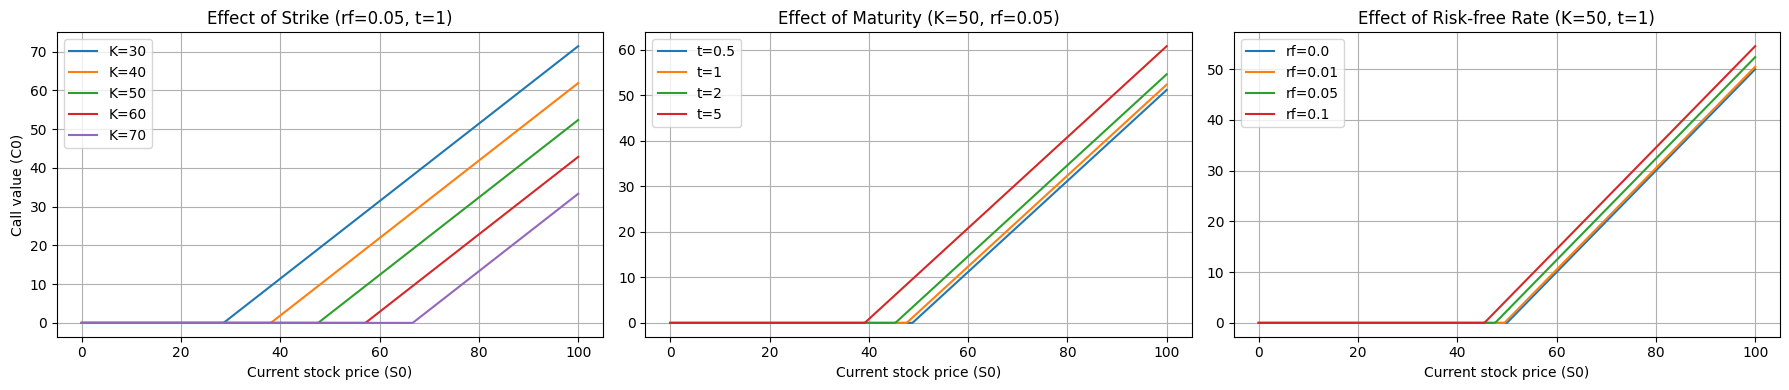

In [ ]:

s0 = np.linspace(0, 100, 401)

strikes = [30, 40, 50, 60, 70]
t_values = [0.5, 1, 2, 5]
rf_values = [0.0, 0.01, 0.05, 0.1]

#this plot is made by Claude Code
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) Effect of strike
ax = axes[0]
for K in strikes:
    ax.plot(s0, callvalue(s0, K, rf=0.05, t=1), label=f'K={K}')
ax.set_xlabel('Current stock price (S0)')
ax.set_ylabel('Call value (C0)')
ax.set_title('Effect of Strike (rf=0.05, t=1)')
ax.grid(True)
ax.legend()

# 2) Effect of maturity
ax = axes[1]
for tval in t_values:
    ax.plot(s0, callvalue(s0, 50, rf=0.05, t=tval), label=f't={tval}')
ax.set_xlabel('Current stock price (S0)')
ax.set_title('Effect of Maturity (K=50, rf=0.05)')
ax.grid(True)
ax.legend()

# 3) Effect of risk-free rate
ax = axes[2]
for rfv in rf_values:
    ax.plot(s0, callvalue(s0, 50, rf=rfv, t=1), label=f'rf={rfv}')
ax.set_xlabel('Current stock price (S0)')
ax.set_title('Effect of Risk-free Rate (K=50, t=1)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# if invest 87.5$ for the risk free asset, you can be equal the stock price
invest1 = risk_free_asset(105, 0.2, 1)
invest2 = s0-invest1
#it says, it is same strategy that i invest the stock
#So, 
# S0 = C0 + E/(1+Rf)^t
# C0 = S0 - E/(1+Rf)^t



87.5

In [73]:
# out-of-the-money
#if s0 = 100, s1 = 110~130, e=120 , the risk_free_asset (under)
s0 = 100
s1 = [110,130]
e = 120
rf = 0.2
t = 1

risk_free_asset(e, rf, t) # is 100

#So, if I invest an option
total_value = []

for i in range(len(s1)):
    if e-s1[i] >= 0:
        total_value.append(risk_free_asset(e, rf, t) * (1+rf)**t)
    else:
        total_value.append(risk_free_asset(e, rf, t) * (1+rf)**t + s1[i]-e)

print(total_value)
# total_value is 120~130, it is different strategy, because it is different the stock's future value

#SO, if i invest to risk free asset on 110$,
total_value = []

for i in range(len(s1)):
    if e-s1[i] >= 0:
        total_value.append(110)
    else:
        total_value.append(110 + s1[i]-e)

print(total_value) # it isn't same the stock prise. so, we invest two of options.

#SO, the c0 is 
c0 = (130 - e) / (1+rf) *1/2
c0

[120.0, 130.0]
[110, 120]


4.166666666666667

In [ ]:
#example 2
s0 = 100
s1 = [105,135]
e = 120
rf = 0.2
t = 1

print(risk_free_asset(e, rf, t)) # is 100

#So, if I invest an option
total_value = []

for i in range(len(s1)):
    if e-s1[i] >= 0:
        total_value.append(105) #105 is case that if i invest to risk free asset on 105$
    else:
        total_value.append(105 + (s1[i]-e)*2)

total_value
#if the stock's price is 135, the call option's value is (135-120)/2 = 7.5 , 7.5/(1+rf)^t = 6.25
# This means that the greater the stock price volatility, the higher the value of the call option.

100.0


TypeError: callvalue() missing 1 required positional argument: 't'